# Quantum Monte Carlo Integration to Estimate Pi Using Quantum Amplitude Estimation 

## Introduction

In this tutorial, we implement a Quantum Monte Carlo Integration (QMCI) circuit to estimate $\pi$.  The approach samples lattice points on a discretized grid and uses Quantum Amplitude Estimation (QAE) to estimate the fraction of points that lie inside a quarter circle. This fraction directly determines the value of $\pi$.  Following Ref.~[1], lattice-based uniform sampling is appropriate for the present $\pi$-estimation problem because the task reduces to estimating the fraction of marked grid points. In this setting, QAE estimates the corresponding amplitude with a quadratic speedup over classical Monte Carlo methods.

This should be distinguished from classical grid-based quadrature, whose cost generally scales exponentially with the dimension. In contrast, the QAE-based QMCI approach can avoid this curse of dimensionality at the level of amplitude estimation. In more general QMCI applications, such as finance, the practical advantage further depends on whether the required probability distribution and oracle can be implemented efficiently.

## Method

The goal of this tutorial is to estimate $\pi$ from the area ratio between a square and an inscribed quarter circle. We sample lattice points $(x,y)$ on a discretized square and determine whether each point lies inside the quarter circle. If the fraction of points inside the quarter circle is denoted by $\alpha$, then

$$
\alpha = \frac{\pi}{4},
$$

and therefore

$$
\pi = 4\alpha.
$$

Two $n$-qubit registers are used to represent the $x$- and $y$-coordinates, respectively:

$$
0 \le x \le 2^n-1,
\qquad
0 \le y \le 2^n-1.
$$

Thus, the computational basis corresponds to $2^{2n}$ lattice points in a square of side length $2^n$. We define the indicator function

$$
f(x,y)=
\begin{cases}
1 & \text{if } x^2+y^2 < 2^{2n},\\
0 & \text{if } x^2+y^2 \ge 2^{2n}.
\end{cases}
$$

With uniform sampling,

$$
p(x,y)=\frac{1}{2^{2n}},
$$

the target quantity is the expectation value

$$
\alpha =
\sum_{x=0}^{2^n-1}
\sum_{y=0}^{2^n-1}
f(x,y)p(x,y).
$$

This is the probability that a uniformly sampled lattice point lies inside the quarter circle.

To estimate this quantity on a quantum computer, we prepare the uniform superposition over all lattice points using

$$
\hat{P}=H^{\otimes 2n},
$$

so that

$$
(\hat{P}\otimes I)|0\rangle_{2n}|0\rangle =
\frac{1}{\sqrt{2^{2n}}}
\sum_{x=0}^{2^n-1}
\sum_{y=0}^{2^n-1}
|x,y\rangle_{2n}|0\rangle .
$$
Then an oracle $\hat{R}$ marks whether each point is inside the quarter circle by writing the value of $f(x,y)$ into an ancilla qubit:
$$
\hat{R}|x,y\rangle_{2n}|0\rangle=
|x,y\rangle_{2n}|f(x,y)\rangle .
$$

Thus,

$$
\hat{R}(\hat{P}\otimes I)|0\rangle_{2n}|0\rangle =
\frac{1}{\sqrt{2^{2n}}}
\sum_{x=0}^{2^n-1}
\sum_{y=0}^{2^n-1}
|x,y\rangle_{2n}|f(x,y)\rangle .
$$


Therefore, the probability of measuring the ancilla qubit in the state $|1\rangle$ is exactly $\alpha$. By applying Quantum Amplitude Estimation (QAE), we estimate this amplitude more efficiently than by classical Monte Carlo integration, and finally compute

$$
\pi = 4\alpha.
$$

Compared with classical grid-based quadrature, whose cost grows exponentially with the dimension, this QAE-based approach avoids the curse of dimensionality. Compared with classical Monte Carlo integration, QAE provides a quadratic speedup in the estimation error. In this $\pi$-estimation task, lattice-based uniform sampling is appropriate because the problem reduces to estimating the fraction of marked grid points. In more general QMCI applications, such as finance, the advantage additionally depends on whether the required probability distribution and oracle can be implemented efficiently.


## Dataset

We first generate the grid data.  $n$ is the parameter for number of data.

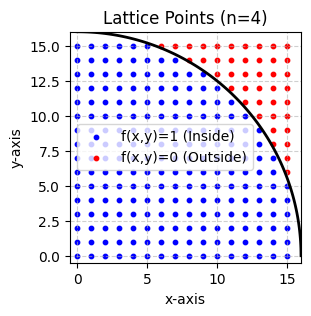

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def plot_pi_sampling(GRID_POINTS_PER_AXIS):
    limit = 2**GRID_POINTS_PER_AXIS
    x_range = np.arange(limit)
    y_range = np.arange(limit)

    X, Y = np.meshgrid(x_range, y_range)

    # constraint: f(x, y) = 1 (True) if x^2 + y^2 < limit^2
    inside = X**2 + Y**2 < limit**2

    plt.figure(figsize=(3, 3))

    # data plot
    plt.scatter(X[inside], Y[inside], color="blue", s=10, label="f(x,y)=1 (Inside)")
    plt.scatter(X[~inside], Y[~inside], color="red", s=10, label="f(x,y)=0 (Outside)")

    theta = np.linspace(0, np.pi / 2, 100)
    plt.plot(limit * np.cos(theta), limit * np.sin(theta), color="black", linewidth=2)

    plt.xlim(-0.5, limit)
    plt.ylim(-0.5, limit)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.title(f"Lattice Points (n={GRID_POINTS_PER_AXIS})")
    plt.xlabel("x-axis")
    plt.ylabel("y-axis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()


plot_pi_sampling(GRID_POINTS_PER_AXIS=4)

## Simulation: Classical Simulation

Below, as a point of comparison, we first present an example of a classical simulation based on uniformly spaced sampling points.


In [2]:
def estimate_pi_grid(GRID_POINTS_PER_AXIS):
    limit = GRID_POINTS_PER_AXIS
    inside_circle = 0
    total_samples = limit * limit

    for y in range(limit):
        for x in range(limit):
            if x**2 + y**2 < limit**2:
                inside_circle += 1

    pi_estimated = (inside_circle / total_samples) * 4
    return pi_estimated


LIST_GRID_POINTS_PER_AXIS = [3, 5, 6]
for mi in LIST_GRID_POINTS_PER_AXIS:
    print(f"(Total Sampling: {mi}²={mi**2}), Estimated Pi: {estimate_pi_grid(mi)}")

(Total Sampling: 3²=9), Estimated Pi: 4.0
(Total Sampling: 5²=25), Estimated Pi: 3.52
(Total Sampling: 6²=36), Estimated Pi: 3.6666666666666665


## Quantum Simulation
### Option 1: QAE based QMCI

In [3]:
import numpy as np

from classiq import *

N_QUBITS = 3


class position(QStruct):
    x: QNum[N_QUBITS]
    y: QNum[N_QUBITS]


@qfunc
def encode_prob(p: position):
    hadamard_transform(p)


@qperm
def oracle_func(p: Const[position], res: QBit):
    fn = 2 ** (2 * N_QUBITS)
    res ^= p.x**2 + p.y**2 < fn


@qfunc
def oracle_op(state: position):
    phase_oracle(oracle_func, state)


@qfunc
def my_grover_operator(state: position):
    grover_operator(
        oracle_op,
        hadamard_transform,
        state,
    )


QPE_SIZE = 3


@qfunc
def main(phase_reg: Output[QNum[QPE_SIZE, UNSIGNED, QPE_SIZE]]):
    state_reg = position()
    allocate(state_reg.size, state_reg)

    allocate(phase_reg)
    encode_prob(state_reg)
    qpe(
        unitary=lambda: my_grover_operator(state_reg),
        phase=phase_reg,
    )
    drop(state_reg)


qprog = synthesize(main)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3EqYbP5JOFnAYoEVgSFVGx1aDAA


In [4]:
result = execute(qprog).result_value()
phases_counts = dict(
    (sampled_state.state["phase_reg"], sampled_state.shots)
    for sampled_state in result.parsed_counts
)

In [5]:
expected_alpha = np.sin(np.pi * max(phases_counts, key=phases_counts.get))
print("QMCI pi = ", expected_alpha * 4)
print("exact pi = ", np.pi)

QMCI pi =  3.695518130045147
exact pi =  3.141592653589793


This result indicates that QMCI successfully approaches the value of $\pi$, although the current estimate still has a significant error compared with the exact value. In the next cell, we investigate how accurately $\pi$ can be estimated by applying IQAE and examining its achievable precision.

### Option2: Iterative QAE based QMCI

In [6]:
from classiq.applications.iqae.iqae import IQAE


def iqae_circuit(N_QUBITS):
    class position(QStruct):
        x: QNum[N_QUBITS]
        y: QNum[N_QUBITS]

    @qfunc
    def encode_prob(p: position):
        hadamard_transform(p)

    @qperm
    def oracle_func(p: Const[position], res: QBit):
        fn = 2 ** (2 * N_QUBITS)
        res ^= p.x**2 + p.y**2 < fn

    @qfunc
    def iqae_state_preparation(p: position, ind: QBit):
        encode_prob(p)
        oracle_func(p, ind)

    iqae = IQAE(
        state_prep_op=iqae_state_preparation,
        problem_vars_size=2 * N_QUBITS,
        constraints=Constraints(optimization_parameter=OptimizationParameter.WIDTH),
        preferences=Preferences(machine_precision=N_QUBITS),
    )
    return iqae

In [7]:
N_QUBITS = 3
qprog = iqae_circuit(N_QUBITS).get_qprog()
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3EqYnWtGGFiRFmeBlePfkD2Q5Nx


### IAQE Parameters

For the numerical test, we use the standard Classiq IAQE routine. The two main parameters are the target accuracy $\epsilon$ and the failure probability $\alpha$.

We set

$$
\epsilon = 0.03,
\qquad
\alpha = 0.01.
$$

Here, $\epsilon$ specifies the target additive accuracy of the amplitude estimation, while $\alpha$ specifies the allowed failure probability. Thus, $\alpha=0.01$ corresponds to a $99%$ confidence level.

This setting is suitable for an initial validation because it keeps the estimation cost moderate while still requiring a reliable confidence level. Once the implementation is verified, $\epsilon$ can be reduced for a higher-precision estimation.


In [8]:
iqae_res = iqae_circuit(N_QUBITS).run(epsilon=0.03, alpha=0.01)

In [9]:
iqae_res.confidence_interval

[0.8731791779970596, 0.881120994691263]

In [10]:
iqae_res.estimation * 4

3.508600345376645

The factor of $4$ is required because IQAE estimates $\pi/4$, corresponding to the area ratio of the quarter circle inside the square.

### Experiment

In this experiment, we examine whether the estimated value approaches the exact solution as the number of qubits increases. Because a larger number of qubits allows exponentially more sampling points to be represented, the discretization becomes finer, and the estimate is expected to become more accurate. By tracking this trend, we can directly evaluate how increasing the qubit number improves the precision of the $\pi$ estimation.


In [11]:
list_expected_value = []
list_conf_err = []
for N_QUBITS in range(1, 5):
    iqae_res = iqae_circuit(N_QUBITS).run(epsilon=0.03, alpha=0.01)
    print("expected pi =", iqae_res.estimation * 4)
    list_expected_value.append(iqae_res.estimation * 4)
    list_conf_err.append(iqae_res.confidence_interval)

expected pi = 3.998328879248948
expected pi = 3.7481528856852786
expected pi = 3.5018416165265203
expected pi = 3.342893743314299


When you run the cell above, you should obtain results similar to those shown below:

In [ ]:
# list_expected_value = [3.998328879248948, 3.7572795311895337, 3.5043386707175443, 3.3476167564481774]
# list_conf_err = [[0.999164439624474, 1.0], [0.9328714567271077, 0.9457683088676591], [0.8720696958863934, 0.8800996394723789], [0.8298663183601778, 0.8439420598639109]]

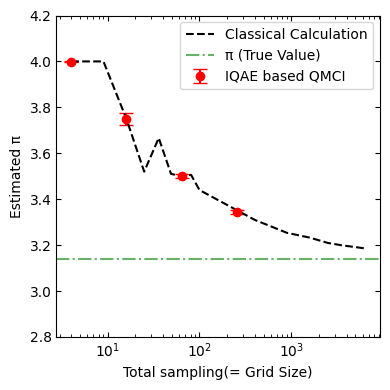

In [12]:
import matplotlib.pyplot as plt
import numpy as np

list_N_QUBITS = range(1, 5)
total_sampling = [2 ** (2 * N_QUBITS) for N_QUBITS in list_N_QUBITS]

pi_ests = list_expected_value

yerr_lower = [pi_ests[i] - (list_conf_err[i][0] * 4) for i in range(len(pi_ests))]
yerr_upper = [(list_conf_err[i][1] * 4) - pi_ests[i] for i in range(len(pi_ests))]

plt.figure(figsize=(4, 4))
plt.tick_params(direction="in", which="both", top=True, right=True)

plt.errorbar(
    total_sampling,
    pi_ests,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="red",
    capsize=5,
    markersize=6,
    label="IQAE based QMCI",
)

LIST_GRID_POINTS_PER_AXIS = np.array(
    [2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80]
)
classical_pi_vals = [estimate_pi_grid(mi) for mi in LIST_GRID_POINTS_PER_AXIS]
plt.plot(
    LIST_GRID_POINTS_PER_AXIS**2,
    classical_pi_vals,
    "--",
    color="black",
    label="Classical Calculation",
)

plt.axhline(y=np.pi, color="green", linestyle="-.", alpha=0.6, label="π (True Value)")

plt.xlabel("Total sampling(= Grid Size)")
plt.ylabel("Estimated π")
plt.ylim(2.8, 4.2)
plt.xscale("log")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

We observe convergence toward the exact value in both the classical and IQAE-based quantum estimates of $\pi$ as the number of sampling points increases.

## Discussion

How much computational advantage can be achieved? According to Ref. [2], the query complexity of QMCI is given by
$$
N_{\mathrm{query}} \approx \frac{C \cdot \ln!\left(\frac{2}{\alpha}\right)}{\epsilon}.
$$
By contrast, in the classical grid-based calculation considered here, all lattice points are evaluated explicitly. Hence, the computational cost is
$$
t_{\mathrm{classical}} = 2^{2n} = \mathcal{O}(1/\epsilon^2).
$$
The table below shows a theoretical comparison of the required number of evaluations and queries.

| Item   | **Classical Grid-Based Integration** | **Quantum Monte Carlo Integration (IQAE)** |
| :----- | :----------------------------------- | :----------------------------------------- |
| $n=2$  | $2^4 = 16$                           | $12,716$                                   |
| $n=4$  | $2^8 = 256$                          | $12,716$                                   |
| $n=10$ | $2^{20} = 1,048,576$                 | $12,716$                                   |

This comparison indicates that the quantum method does not provide an advantage at small scales, but becomes more efficient than the classical approach once the problem size is sufficiently large.

## References 
[1] [Quantum circuit to estimate pi using quantum amplitude estimation](https://arxiv.org/abs/2008.02623)

[2] [Iterative Quantum Amplitude Estimation, Granko et al., 2019](https://www.nature.com/articles/s41534-021-00379-1)